In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Import Library

In [ ]:
!pip install rarfile

In [ ]:
import tensorflow as tf
import os
import shutil
import rarfile
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

## Cek GPU

In [ ]:
device_name = tf.test.gpu_device_name()
if len(device_name) > 0:
    print("Found GPU at: {}".format(device_name))
else:
    device_name = "/device:CPU:0"
    print("No GPU, using {}.".format(device_name))

Found GPU at: /device:GPU:0


## Constant

In [ ]:
IMAGE_SIZE = 256
BATCH_SIZE = 32
N_CLASSES = 10
CHANNELS = 3
EPOCHS = 60

## Extract RAR File

In [ ]:
local_rar = '/content/drive/MyDrive/Proyek Data Mining/Tomatos_Dataset_Zip/Tomato.rar'
extract_dir = '/content'
with rarfile.RarFile(local_rar, 'r') as rf:
    rf.extractall(extract_dir)

## Data Splitting

In [ ]:
training_dir = os.path.join('/content', 'Tomato')
validation_dir = '/content/Tomato_validation'
test_dir = '/content/Tomato_test'
!mkdir '/content/Tomato_validation'
!mkdir '/content/Tomato_test'

def split_data(from_dir, destination_dir, dataset_portion):
    for class_dir_name in os.listdir(from_dir):
        class_dir_path = os.path.join(from_dir, class_dir_name)
        from_dataset_num = len(os.listdir(class_dir_path))

        val_dataset_num = int(from_dataset_num * dataset_portion)

        des_class_dir_path = os.path.join(destination_dir, class_dir_name)
        if os.path.exists(des_class_dir_path):
            shutil.rmtree(des_class_dir_path)

        os.mkdir(des_class_dir_path)

        counter = 0

        for file_name in os.listdir(class_dir_path):
            filepath = os.path.join(class_dir_path, file_name)
            if counter < val_dataset_num:
                destination = os.path.join(des_class_dir_path, file_name)
                shutil.move(filepath, destination)
                counter += 1

test_dataset_portion = 0.2
validation_dataset_portion = 0.5

split_data(training_dir, test_dir, test_dataset_portion)
split_data(test_dir, validation_dir, validation_dataset_portion)

## Data Normalization and Data Augmentation

In [ ]:
training_datagen = tf.keras.preprocessing.image.ImageDataGenerator (
    rescale=1./255,
    horizontal_flip=True,
    vertical_flip=True,
    rotation_range=20
)
val_test_datagen = tf.keras.preprocessing.image.ImageDataGenerator (
    rescale=1./255
)

## Load Dataset

In [ ]:
training_generator = training_datagen.flow_from_directory(
    training_dir,
    target_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True
)

validation_generator = val_test_datagen.flow_from_directory(
    validation_dir,
    target_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True
)

test_generator = val_test_datagen.flow_from_directory(
    test_dir,
    target_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

Found 12813 images belonging to 10 classes.
Found 1597 images belonging to 10 classes.
Found 1601 images belonging to 10 classes.


## Model Architecture

In [ ]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Conv2D(32, kernel_size = (3,3), activation='relu', input_shape=(IMAGE_SIZE, IMAGE_SIZE, CHANNELS)),
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.Conv2D(64,  kernel_size = (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.Conv2D(64,  kernel_size = (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.Conv2D(64, kernel_size = (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.Conv2D(64, kernel_size = (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.Conv2D(64, kernel_size = (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(N_CLASSES, activation='softmax'),
])

In [ ]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 254, 254, 32)      896       
                                                                 
 max_pooling2d (MaxPooling2  (None, 127, 127, 32)      0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 125, 125, 64)      18496     
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 62, 62, 64)        0         
 g2D)                                                            
                                                                 
 conv2d_2 (Conv2D)           (None, 60, 60, 64)        36928     
                                                                 
 max_pooling2d_2 (MaxPoolin  (None, 30, 30, 64)        0

In [ ]:
model.compile (
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

## Training Model

In [ ]:
early_stopping_callback = tf.keras.callbacks.EarlyStopping(
    monitor='val_accuracy',
    patience=45,
    mode='max',
    verbose=1,
    min_delta=0.01,
    baseline=0.98)

In [ ]:
history = model.fit(
    training_generator,
    epochs=EPOCHS,
    verbose=1,
    validation_data=validation_generator,
    callbacks=[early_stopping_callback]
)

Epoch 1/60
401/401 [==============================] - 228s 547ms/step - loss: 1.6722 - accuracy: 0.4065 - val_loss: 1.3308 - val_accuracy: 0.5379
Epoch 2/60
401/401 [==============================] - 219s 545ms/step - loss: 0.9892 - accuracy: 0.6573 - val_loss: 1.1005 - val_accuracy: 0.6180
Epoch 3/60
401/401 [==============================] - 219s 546ms/step - loss: 0.6837 - accuracy: 0.7622 - val_loss: 0.8849 - val_accuracy: 0.7214
Epoch 4/60
401/401 [==============================] - 215s 537ms/step - loss: 0.5395 - accuracy: 0.8109 - val_loss: 0.5233 - val_accuracy: 0.8240
Epoch 5/60
401/401 [==============================] - 218s 543ms/step - loss: 0.4403 - accuracy: 0.8439 - val_loss: 1.2082 - val_accuracy: 0.6919
Epoch 6/60
401/401 [==============================] - 214s 533ms/step - loss: 0.3849 - accuracy: 0.8655 - val_loss: 0.9611 - val_accuracy: 0.7539
Epoch 7/60
401/401 [==============================] - 214s 532ms/step - loss: 0.3313 - accuracy: 0.8829 - val_loss: 1.0370 -

## Evaluate Model

In [ ]:
test_loss, test_accuracy = model.evaluate(test_generator)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

51/51 [==============================] - 4s 69ms/step - loss: 0.1379 - accuracy: 0.9569
Test Loss: 0.13789725303649902
Test Accuracy: 0.9569019079208374


## Accuracy & Loss Curves

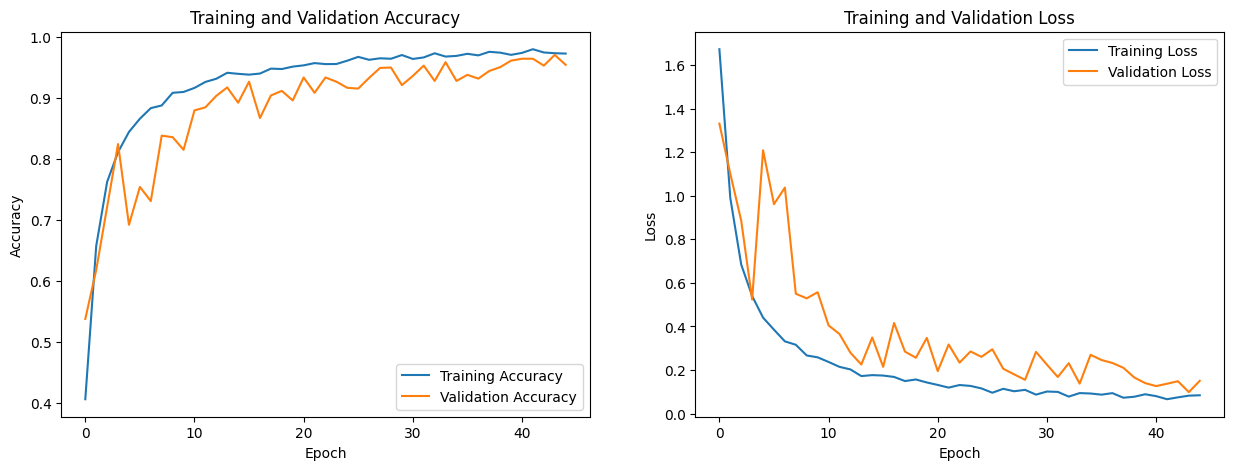

In [ ]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(45)

plt.figure(figsize=(15, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.show()

## Confusion Matrix

<ipython-input-18-d3f38f7eec29>:3: UserWarning: `Model.predict_generator` is deprecated and will be removed in a future version. Please use `Model.predict`, which supports generators.
  predictions = model.predict_generator(test_generator)


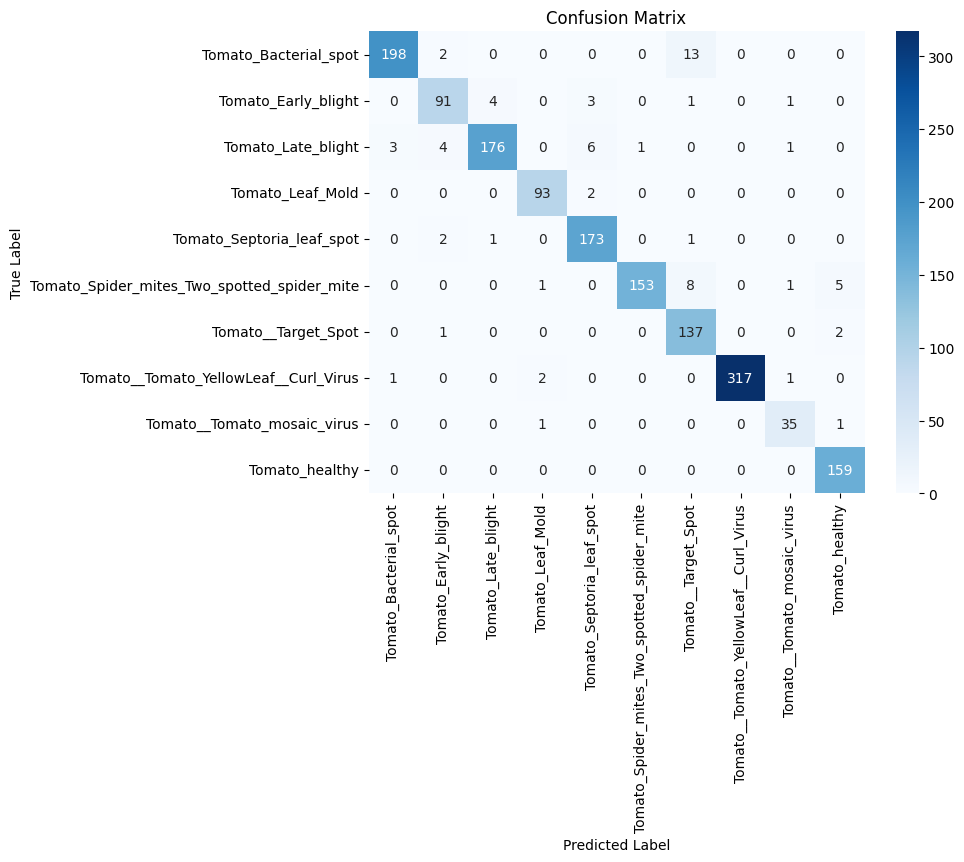

In [ ]:
import numpy as np

predictions = model.predict_generator(test_generator)
predicted_classes = np.argmax(predictions, axis=1)
true_classes = test_generator.classes
class_labels = list(test_generator.class_indices.keys())
confusion_mtx = confusion_matrix(true_classes, predicted_classes)

plt.figure(figsize=(8, 6))
sns.heatmap(confusion_mtx, annot=True, fmt='d', xticklabels=class_labels, yticklabels=class_labels, cmap='Blues')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

## Accuracy, Precision, Recall, F1-score

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

predictions = model.predict_generator(test_generator)
predicted_classes = np.argmax(predictions, axis=1)

true_classes = test_generator.classes

accuracy = accuracy_score(true_classes, predicted_classes)
precision = precision_score(true_classes, predicted_classes, average='weighted')
recall = recall_score(true_classes, predicted_classes, average='weighted')
f1 = f1_score(true_classes, predicted_classes, average='weighted')

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)

<ipython-input-19-9d875a900b1e>:3: UserWarning: `Model.predict_generator` is deprecated and will be removed in a future version. Please use `Model.predict`, which supports generators.
  predictions = model.predict_generator(test_generator)


Accuracy: 0.9569019362898189
Precision: 0.959012704721253
Recall: 0.9569019362898189
F1-score: 0.9571139682711084


## Save Model

In [ ]:
model.save('/content/drive/MyDrive/Proyek Data Mining/Model/Model1.h5')

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(
